In [1]:
import matplotlib.pyplot as plt
import torch

In [2]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

train_set = dataset["train"]
train_iter = iter(train_set)
train_set_map = train_set

test_set = dataset["test"]
test_iter = iter(test_set)
test_set_map = test_set

In [3]:
# DATASET SIZES
print(f"Training set size: {len(train_set_map)}")
print(f"Test set size: {len(test_set_map)}")

# Unique labels
labels_set = {label for label, _ in train_set_map}
print(f"The set of unique labels: {labels_set}")

Training set size: 120000
Test set size: 7600
The set of unique labels: {'text'}


In [4]:
labels_list = [sample["label"] + 1 for sample in train_set_map]
labels_tensor = torch.tensor(labels_list)

# Count the frequency of each label
unique_labels, count = torch.unique(labels_tensor, return_counts=True)
label_dict = {1: "World", 2: "Sports", 3: "Business", 4: "Science & Technology"}

# PRINTING SOME SAMPLES FOR EACH LABEL
print_sample_size = 2

for label in unique_labels:
    count = 0
    print(f'Some samples with label {label}, corresponding to category "{label_dict[int(label)]}"')

    for sample in train_set_map:
        if sample["label"] + 1 == int(label):
            print(sample["text"])
            count += 1
            print(" ")

            if count >= print_sample_size:
                break

    print("-----------------------------------------------------------------------------------------------------------")

Some samples with label 1, corresponding to category "World"
Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.
 
S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controversial decision to\send more troops to Iraq.
 
-----------------------------------------------------------------------------------------------------------
Some samples with label 2, corresponding to category "Sports"
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the even

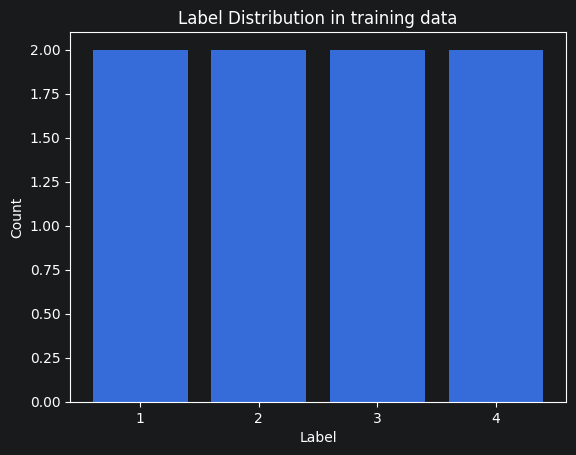

In [5]:
# Plotting the histogram for label distribution
plt.bar(unique_labels, count, tick_label=list(range(1, 5)))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution in training data")
plt.show()